In [431]:
import torch 
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [432]:
live = pd.read_csv("../data/samples/trial/live_metrics.csv")
verbose = pd.read_csv("../data/samples/trial/verbose_statements.csv")
initial = pd.read_csv("../data/samples/trial/initial_statement.csv")

In [433]:
live = live.drop(columns=['Unnamed: 0'])

In [443]:
data

[[tensor([0.0000, 0.0000, 0.0978]), tensor([2.6066])],
 [tensor([0.0000, 0.0000, 0.0978]), tensor([0.5222])],
 [tensor([0.0000, 0.0000, 0.0978]), tensor([2.5830])],
 [tensor([0.0200, 0.0200, 0.5489]), tensor([0.9559])],
 [tensor([0.0400, 0.0300, 1.0000]), tensor([1.1452])],
 [tensor([0.0400, 0.0300, 1.0000]), tensor([6.3868])],
 [tensor([0.7954, 0.5243, 1.0000]), tensor([122.6408])],
 [tensor([0.8264, 0.5500, 1.0000]), tensor([27.9756])],
 [tensor([0.8254, 0.5597, 1.0000]), tensor([7.8533])],
 [tensor([0.8292, 0.5700, 1.0000]), tensor([20.5510])],
 [tensor([0.8400, 0.5700, 1.0000]), tensor([0.4336])],
 [tensor([0.8400, 0.5700, 1.0000]), tensor([0.6529])],
 [tensor([0.8400, 0.5700, 1.0000]), tensor([1.4754])],
 [tensor([0.8150, 0.5583, 1.0000]), tensor([2.5214])],
 [tensor([0.7900, 0.5500, 1.0000]), tensor([5.9087])],
 [tensor([0.7900, 0.5500, 1.0000]), tensor([5.4111])],
 [tensor([0.7986, 0.5329, 1.0000]), tensor([7.6063])],
 [tensor([0.8000, 0.5300, 1.0000]), tensor([5.9494])],
 [tens

In [434]:
response_time = verbose['total_duration'].tolist()
response_time = response_time[:-1]
reset_iters = live[live['Iteration'] == 1].index.tolist()

gpu_util_avg = []
memory_util_avg = []
clock_util_avg = []

for i in range(1, len(reset_iters)):
    temp_metrics = live.dropna()
    gpu_util_prompt= temp_metrics.iloc[reset_iters[i-1]:reset_iters[i], 3].tolist()
    memeory_util_prompt= temp_metrics.iloc[reset_iters[i-1]:reset_iters[i], 9].tolist()
    clock_util_prompt= temp_metrics.iloc[reset_iters[i-1]:reset_iters[i], -2].tolist()
    gpu_util_avg.append(np.average(gpu_util_prompt))
    memory_util_avg.append(np.average(memeory_util_prompt))
    clock_util_avg.append(np.average(clock_util_prompt))

In [435]:
data = []

for (x, y, z, i) in zip(gpu_util_avg, memory_util_avg, clock_util_avg, response_time[:-1]):
    data.append([torch.Tensor([x, y, z]), torch.Tensor([i])])

In [436]:
class BenchMark(nn.Module):
    def __init__(self, input_features, output_features):
        super().__init__()
        self.l1 = nn.Sequential(
            nn.Linear(input_features, 32),
            nn.ReLU()
        )
        self.l2 = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU()
        )
        self.l3 = nn.Linear(16, output_features)

    def forward(self, x):
        x = self.l1(x)
        x = self.l2(x)
        x = self.l3(x)
        return x

In [437]:
model = BenchMark(3, 3)

In [438]:
def minimize_avg_time_loss(predicted, nums, ans):
    total_sum = 0
    for i in range(3):
        total_sum += (predicted[0][i]*nums[i]) 
    loss = nn.MSELoss()
    net_loss = loss(total_sum, ans) 
    return net_loss

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

In [439]:
train_data = data[:50]
test_data = data[50:]

train_dataloader = DataLoader(train_data, batch_size=10, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=10, shuffle=True)

In [440]:
model.train()
total_loss = []
for batch, (X, y) in enumerate(train_dataloader):
    for X_mini, y_mini in zip(X, y):
        preds = model(X)
        loss = minimize_avg_time_loss(preds, X_mini, y_mini)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss.append(loss.detach().numpy())
        print("Current Loss: ")
        print(loss)

Current Loss: 
tensor(84.6544, grad_fn=<MseLossBackward0>)
Current Loss: 
tensor(0.7899, grad_fn=<MseLossBackward0>)
Current Loss: 
tensor(38.7251, grad_fn=<MseLossBackward0>)
Current Loss: 
tensor(16.7726, grad_fn=<MseLossBackward0>)
Current Loss: 
tensor(11.1270, grad_fn=<MseLossBackward0>)
Current Loss: 
tensor(54.5922, grad_fn=<MseLossBackward0>)
Current Loss: 
tensor(0.4160, grad_fn=<MseLossBackward0>)
Current Loss: 
tensor(97.0357, grad_fn=<MseLossBackward0>)
Current Loss: 
tensor(355.3562, grad_fn=<MseLossBackward0>)
Current Loss: 
tensor(29.5081, grad_fn=<MseLossBackward0>)
Current Loss: 
tensor(333.8386, grad_fn=<MseLossBackward0>)
Current Loss: 
tensor(0.5206, grad_fn=<MseLossBackward0>)
Current Loss: 
tensor(100.6825, grad_fn=<MseLossBackward0>)
Current Loss: 
tensor(119.2803, grad_fn=<MseLossBackward0>)
Current Loss: 
tensor(71.4194, grad_fn=<MseLossBackward0>)
Current Loss: 
tensor(8.8130, grad_fn=<MseLossBackward0>)
Current Loss: 
tensor(0.2829, grad_fn=<MseLossBackward0>

c:\Users\rahul\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


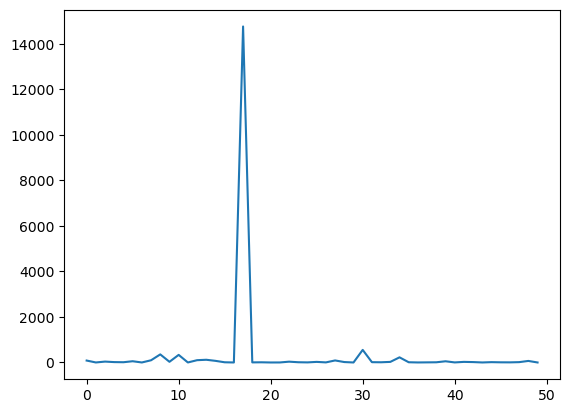

In [441]:
y = pd.Series(total_loss)
x = range(len(response_time[:50]))
plt.plot(x, y)
plt.show()